---
numbering: false
---

# 1.1. What is Machine Learning?

If you're reading this, you've chosen to take a course that explores the mathematical foundations of machine learning, with a particular focus on linear algebra. I'm not going to assume you know anything about machine learning or linear algebra. But, before I dive into any details, I do want to give you a sense of what machine learning actually is, and how recent advances like ChatGPT – which you almost certainly know something about – connect to what you'll learn.

## Motivation

### Example: Handwritten Digit Recognition

Using your mouse, draw a **✍️ digit in the box below**. As you draw, a _model_ ([source](https://mco-mnist-draw-rwpxka3zaa-ue.a.run.app)) will try and guess the digit you're drawing, and describe how confident it is in its guess.

In [1]:
from IPython.display import HTML

html_content = """
<div style="height: 750px; overflow: hidden; position: relative; background: white;">
    <iframe src="https://mco-mnist-draw-rwpxka3zaa-ue.a.run.app/?embed=1" 
            width="700" 
            height="1000" 
            style="border: none; position: absolute; top: -270px; left: 0;">
    </iframe>
</div>
"""

HTML(html_content)

Draw a few different digits, and hit "clear" after each one. You'll notice that the model isn't perfect (for instance, it often confuses my 0s with 2s, 5s, 7s, and 9s, depending on where in the box I draw the 0), but it works reasonably well.

**How did the model figure out how to identify digits, and why is it sometimes wrong?**

If you were to implement such a model, one technique you _could_ try is to hardcode a bunch of `if`-statements that check for certain patterns in the digit you drew. For example, you could check if the digit has a straight line in the middle, as that would make it likely to be a 1, 7, or 9; or if it has a closed loop, as that would make it likely to be a 0, 2, 4, 6, 8, or 9. But, this is very tedious, and requires you to have a deep understanding of the patterns that make up each digit. And if there were 100 possible digits instead of 10, this would be much more difficult.

### The Machine Learning Way

Machine learning uses a different approach. **Machine learning is about automatically learning patterns from data.**

In the case of the digit recognition model, the creators of the model showed the model thousands of pictures of handwritten digits, **along with the correct answer for each digit**. These correct answers are called **labels**. The model then used this data to learn the patterns that make up each digit. This process, of having a model learn the patterns of the data so that we can use it to make predictions, is called **training** the model.

The specific dataset this model was trained on is called the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), a common dataset used to test and benchmark machine learning models.

:::{figure} 01-intro-imgs/mnist.png
:figclass: with-caption center

A few of the images in the MNIST dataset.
:::

I'm using the term "model" loosely here. One, I haven't formally defined the term, and I also haven't actually specified _how_ the model makes its guesses. There are plenty of types of models that we could train for the purposes of digit recognition – neural networks are the most popular choice these days, but decision trees, support vector machines, logistic regression, and so on are all reasonable choices. More flexible models can learn more complex patterns, but come with the risk of overfitting to the training data; this is an idea we'll discuss more in [Chapter 1.2](02-squared-loss-constant-model.ipynb).

The MNIST database contains 70,000 images of handwritten digits, each of which is grayscale (no color) and 28x28 pixels. The dataset contains the true labels for each image – that is, the model is told that the first row above contains all 0s, the second row contains all 1s, and so on. If we wanted to instead build a model that could guess whether an image is of a cat, dog, or hamster, we'd need to show the model many labeled images of cats, dogs, and hamsters.

### A Brief History

Machine learning – and more recently, _artificial intelligence_ – are hot topics these days, and indeed, new breakthroughs appear every few months. But, the origins of the field are much, much older than you and me.

Linear regression, which I think of as the foundation of machine learning, was first used in the early 1800s by physicists Legendre and Gauss to predict the motions of bodies in the solar system. That's the same <span style="color:orange">Gauss</span> behind the <span style="color:orange">Gauss</span>ian distribution, i.e. normal distribution or bell curve, that is ubiquitous in statistics and that we'll study in a later chapter on probability. (In particular, we'll learn about how the normal distribution plays a role in machine learning.)

:::{figure} 01-intro-imgs/gauss.gif
:width: 300
:figclass: with-caption center

An early sketch by Gauss, when trying to determine the motion of the planet Ceres, for which he developed the method of least squares.
:::

Regression was then given the name "regression" and further developed by Galton and Pearson in the late 1800s to predict the heights of children given the heights of their parents. [Galton](https://en.wikipedia.org/wiki/Francis_Galton) was the cousin of Charles Darwin and was the originator of the field of eugenics, which led to a dark period in history.

Neural networks, which power most of the advances you've heard of recently, were [first developed by neuroscientists in the 1940s](https://en.wikipedia.org/wiki/History_of_artificial_neural_networks) to model the behavior of neurons in the brain. For now, think of a neural network as a sophisticated type of model that can be trained on data to make predictions. The popularity of neural networks skyrocketed in the early 2010s, after they were [shown to outperform traditional AI-but-not-neural-network-based models](https://en.wikipedia.org/wiki/ImageNet) on tasks like image recognition. This improvement in performance was made possible by several factors, including new mathematical techniques but also the advent of GPUs that made it possible to train models on large datasets efficiently. (I'll touch more on what a GPU is and why they're relevant in a later chapter.)

The physicists and statisticians of the 1800s did not think they were "doing" machine learning, as that term only came into use in the 1960s. To hear more about how machine learning and statistics are related fields, but with slightly different goals, read the famous [Two Cultures](https://www.jstor.org/stable/2676681?seq=1) paper by Leo Breiman. And if you want to know more about the history of statistics, machine learning, and computer science, [this seminar course](https://historyofdsc.com/) I taught at UC San Diego might be of interest to you.

:::{warning} Focus on the Ideas!
The rest of this section will move quickly and introduce a lot of new ideas. Focus on just the big-picture ideas. Any relevant mathematical details will be re-introduced in [Chapter 1.2](02-squared-loss-constant-model.ipynb) onward.
:::

---

## Supervised Learning

There are several types of problems that we can use machine learning to solve. The taxonomy below shows _some_ of them.

:::{figure} 01-intro-imgs/ml-taxonomy.svg
:width: 600
:figclass: with-caption center

Source: [Sam Lau](https://lau.ucsd.edu/)
:::

Supervised learning is the type of machine learning that we'll spend most of our time on, and the digit recognition problem from above is an example of a supervised learning problem.

:::{note} Definition: Supervised Learning

A supervised learning problem can be thought of as "given data, **predict** a label", or "given $x$, predict $y$".

To train a model for a supervised learning problem, we need to have a dataset that contains information about each individual, along with the correct label for each individual.
:::

The "supervising" comes from having a correct answer (label) for each situation in the dataset; you can think of the computer as being "supervised" by the correct answers.

There are two types of supervised learning problems: classification and regression.

### Classification

In a classification problem, the label is a category, i.e. a categorical variable, with a finite number of possible values.

| Example | Labels |
|---------|--------|
| Digit recognition | 0, 1, 2, 3, 4, 5, 6, 7, 8, or 9 |
| <span style="color:#d81b60">Email spam detection</span> | <span style="color:#d81b60">"spam" or "not spam"</span> |
| Image classification | "dog", "cat", "hamster", or "zebra" |
| <span style="color:#d81b60">Medical diagnosis</span> | <span style="color:#d81b60">"diabetes" or "no diabetes"</span> |
| Risk assessment | "low risk", "medium risk", or "high risk" |

The <span style="color:#d81b60">email spam detection</span> and <span style="color:#d81b60">medical diagnosis</span> problems are **binary** classification problems, as there are only two possible labels. In binary classification problems, we typically represent the labels as 1 (spam, diabetes) and 0 (not spam, no diabetes).

As another example, suppose we have a dataset of penguins. For each penguin in the dataset, we know its bill length in millimeters, its body mass in grams, and its species, which is either Adelie, Chinstrap, or Gentoo. The dataset shown below reflects real data about real penguins in Antarctica; read more about the dataset [here](https://allisonhorst.github.io/palmerpenguins/articles/intro.html).

In [27]:
import seaborn as sns
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)
from sklearn.model_selection import train_test_split
import intro_util as util

X_train, X_test, y_train, y_test = train_test_split(
    penguins[['bill_length_mm', 'body_mass_g', 'bill_depth_mm']],
    penguins['species'],
    random_state=26
)

disp = X_train.assign(species=y_train)[['bill_length_mm', 'body_mass_g', 'species']].reset_index(drop=True)
disp.columns = ['Bill Length', 'Body Mass', 'Species (Label)']

def color_species(val):
    color_map = {
        'Adelie': 'color: #FFA14E; font-weight: bold',
        'Chinstrap': 'color: #B97AC9; font-weight: bold',
        'Gentoo': 'color: #4CA3A3; font-weight: bold'
    }
    return color_map.get(val, '')

# Create table styles for column borders
table_styles = [
    {'selector': 'th.col2', 'props': 'border-left: 4px solid #000; border-top: 4px solid #000; border-right: 4px solid #000'},
    {'selector': 'td.col2', 'props': 'border-left: 4px solid #000; border-right: 4px solid #000'},
    {'selector': 'tbody tr:last-child td.col2', 'props': 'border-bottom: 4px solid #000'}
]

disp.head(10).style.map(color_species, subset=['Species (Label)']).set_table_styles(table_styles)

,Bill Length,Body Mass,Species (Label)
0,43.200000,4100.000000,Adelie
1,43.200000,4775.000000,Adelie
2,46.200000,5300.000000,Gentoo
3,50.200000,3775.000000,Chinstrap
4,51.300000,3700.000000,Chinstrap
5,48.200000,5100.000000,Gentoo
6,40.100000,4300.000000,Adelie
7,36.000000,3450.000000,Adelie
8,43.500000,4700.000000,Gentoo
9,50.900000,3675.000000,Chinstrap


The **boxed column** contains the labels for each penguin. Think of this as the "$y$" in "given $x$, predict $y$", or as the answer key.

We can use a scatter plot to visualize the relationship between body mass and bill length, with colors indicating the species.

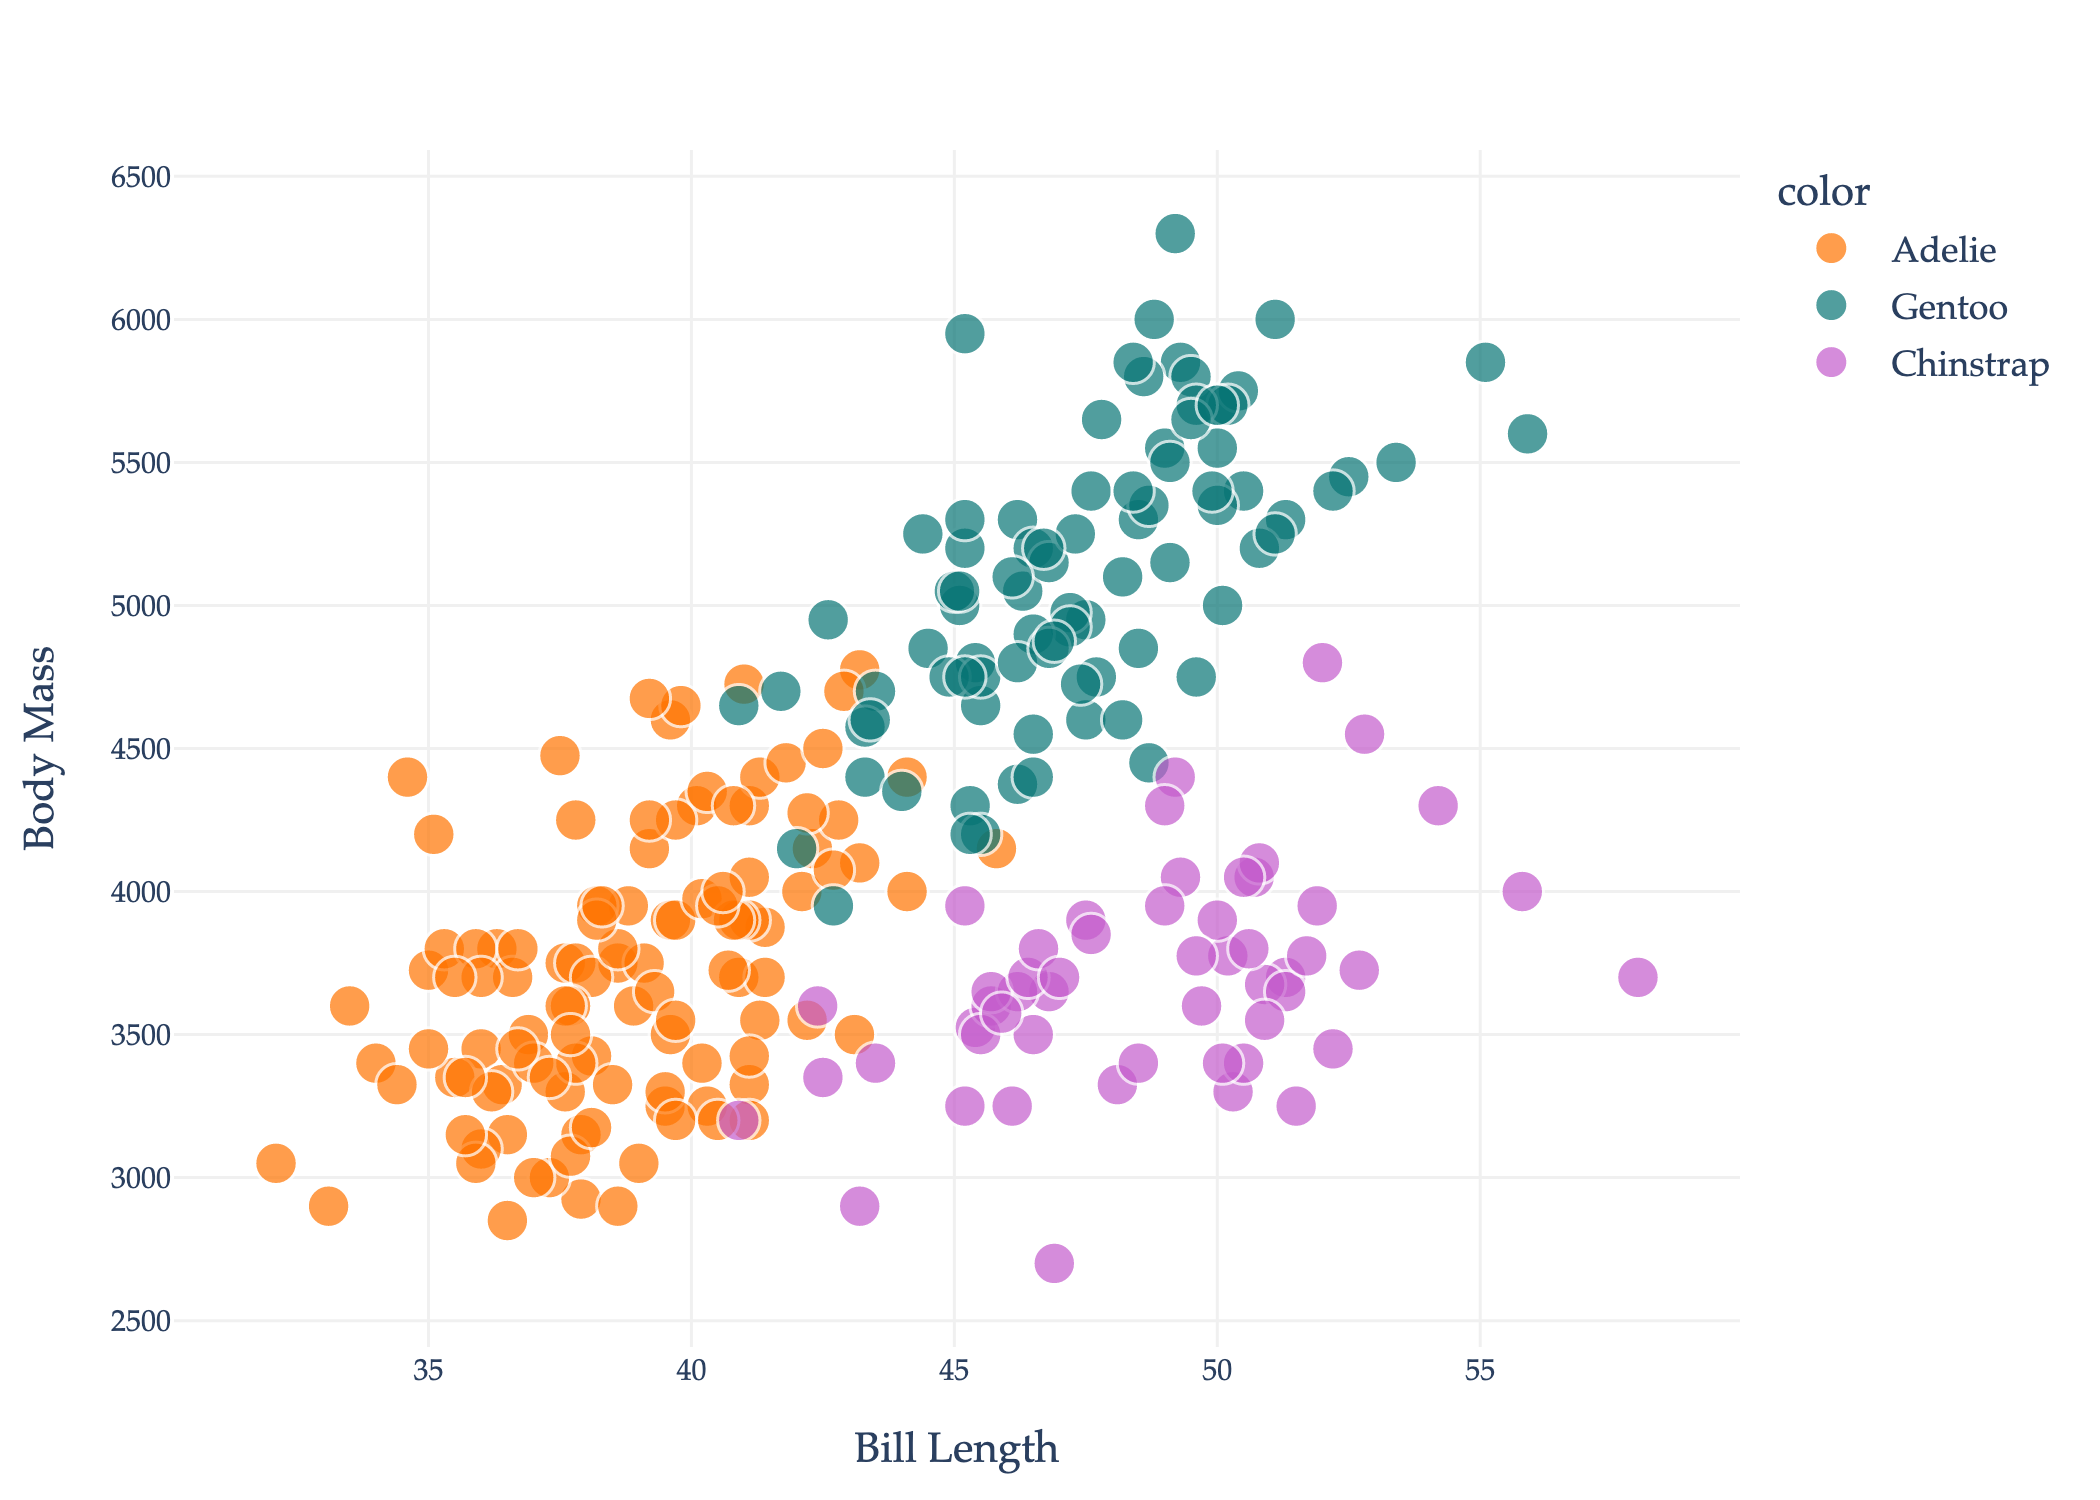

In [13]:
util.penguin_scatter_2d(X_train, y_train).update_layout(title='', width=700, height=500, showlegend=True).show(renderer='png', scale=3)

Fun fact: our local [Detroit Zoo](https://penguins.detroitzoo.org/the-penguins/) is home to Chinstrap and Gentoo penguins.

Once we train a model to predict the species of penguins, we can use it to predict the species of **new** penguins who weren't in our original dataset. All models for this task take the form of a function $h$:

$$
\text{predicted species}_i = h(\text{bill length}_i, \text{body mass}_i)
$$

where $h$ can only output one of three things: <span style="color:#FFA14E; font-weight:bold">Adelie</span>, <span style="color:#B97AC9; font-weight:bold">Chinstrap</span>, or <span style="color:#4CA3A3; font-weight:bold">Gentoo</span>.

The **decision boundaries** of two different models – that is, two different functions $h$ – are shown below. The regions are colored based on what the model would predict for a new penguin.

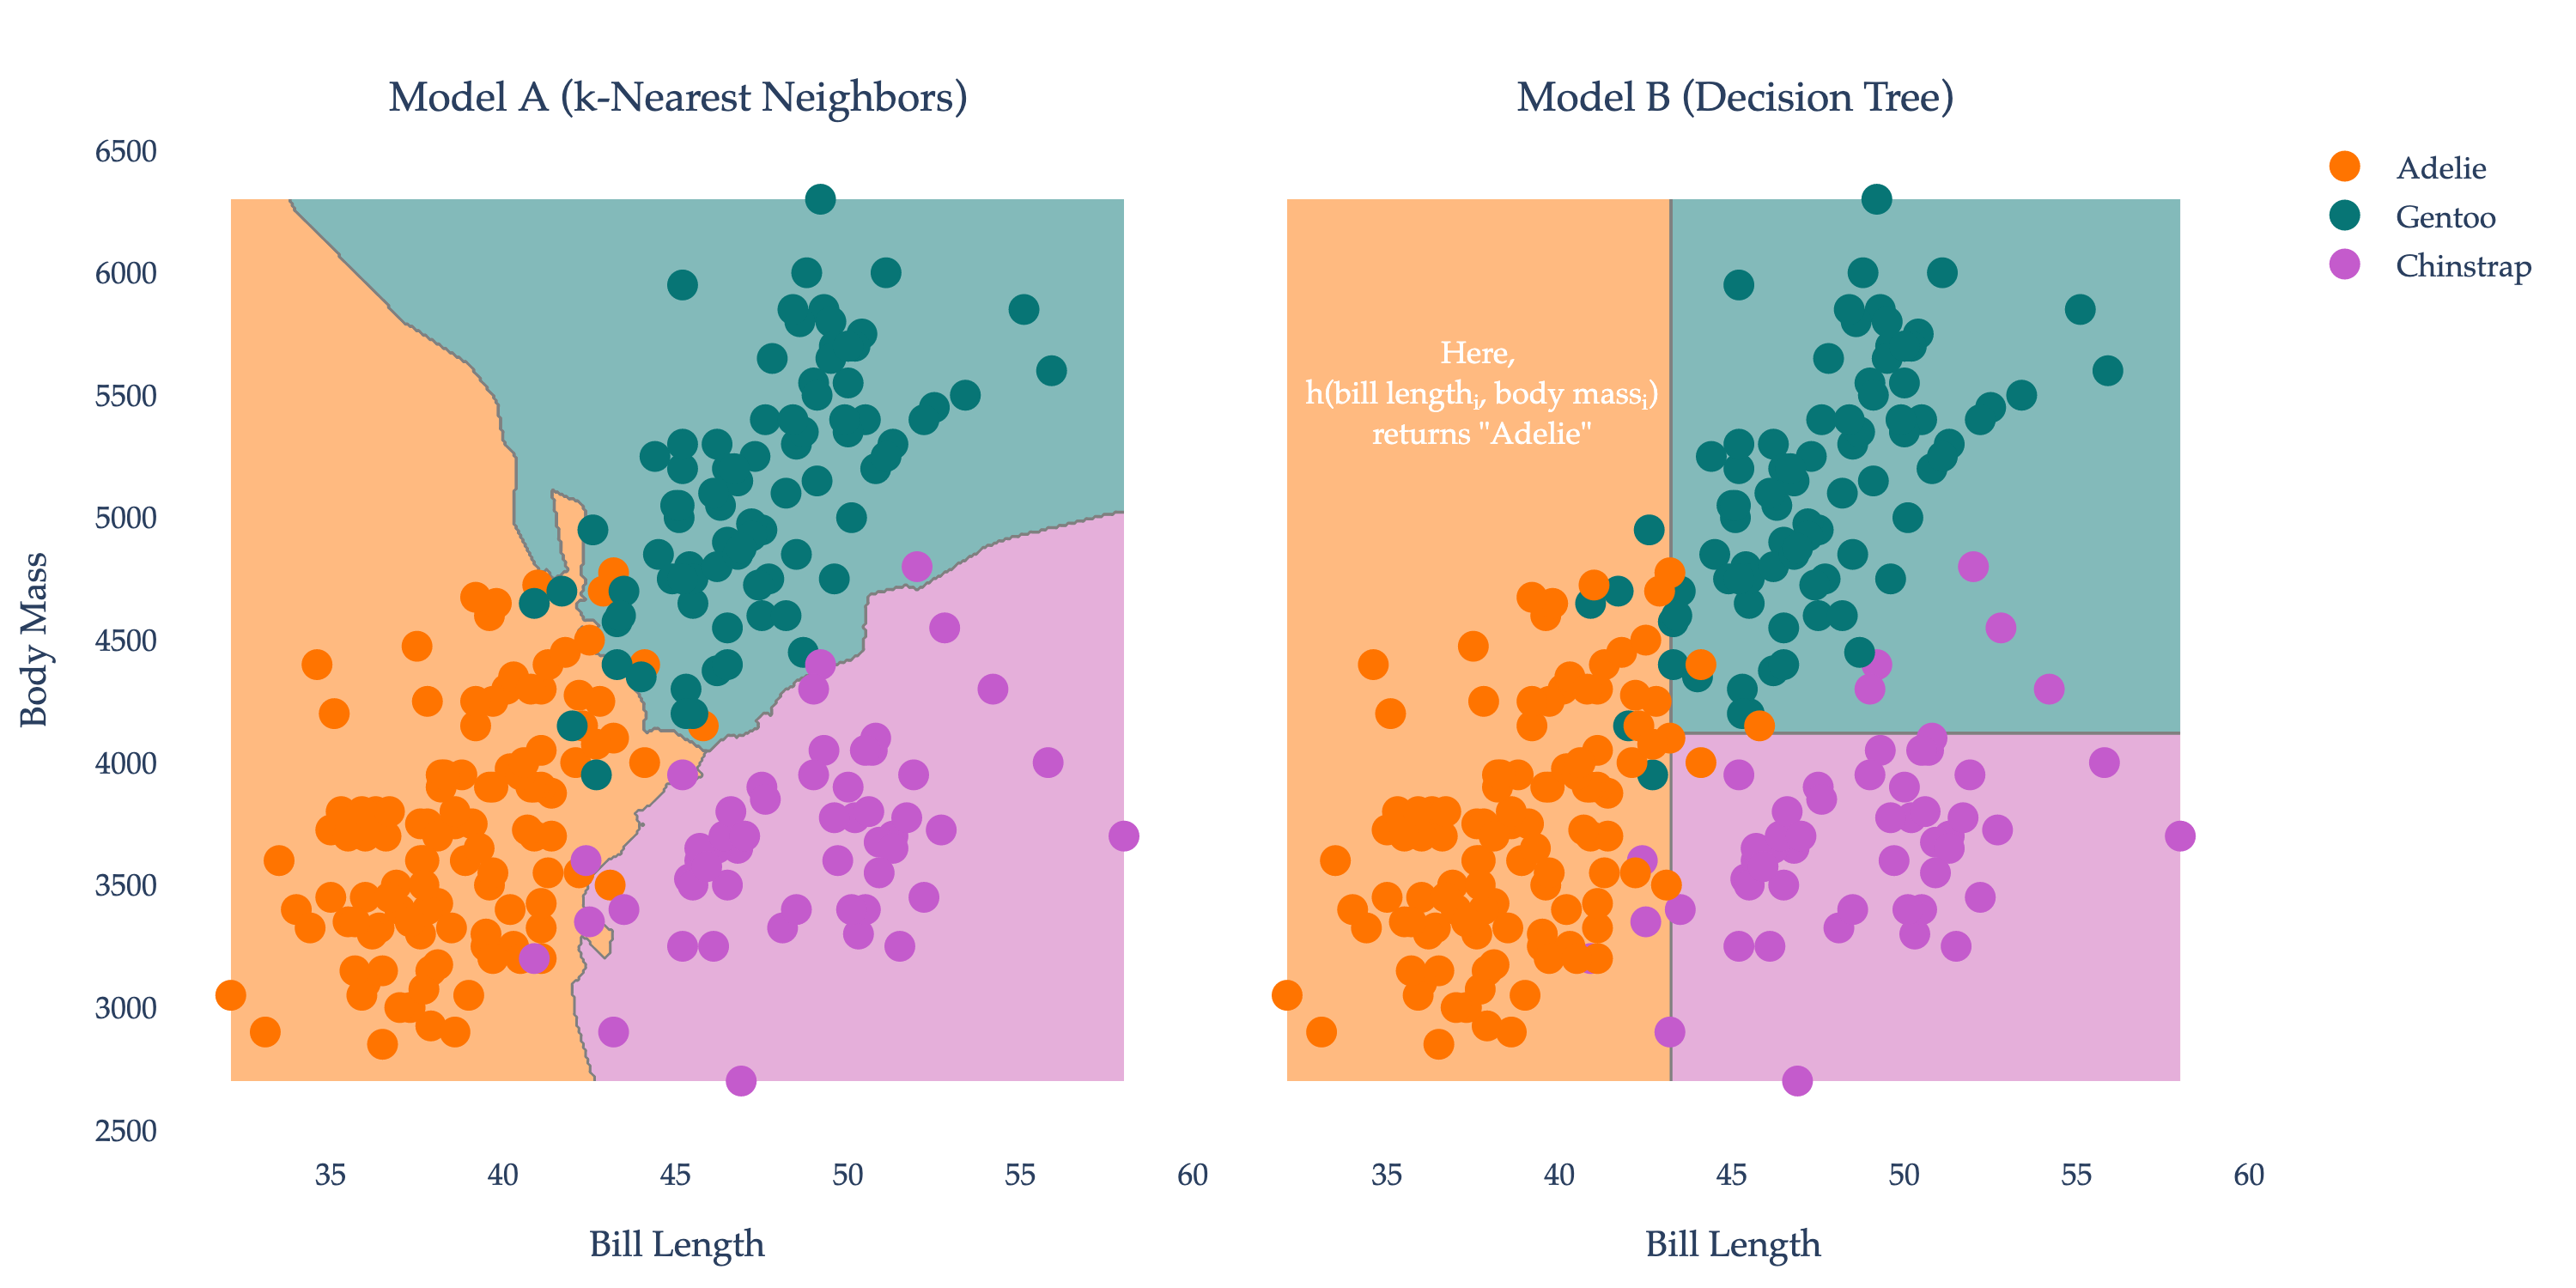

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import intro_util as util
from plotly.subplots import make_subplots
import plotly.graph_objects as go

X_train, X_test, y_train, y_test = train_test_split(penguins[['bill_length_mm', 'body_mass_g', 'bill_depth_mm']], 
                                                    penguins['species'], 
                                                    random_state=26)

model_knn_standardized = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
model_knn_standardized.fit(X_train.iloc[:, :-1].to_numpy(), y_train)
fig1 = util.penguin_decision_boundary(model_knn_standardized, X_train, y_train, title="k-NN Decision Boundary when k = 5 and with Standardization")

model_tree = DecisionTreeClassifier(max_depth=2)
model_tree.fit(X_train.iloc[:, :-1].to_numpy(), y_train)
fig2 = util.penguin_decision_boundary(model_tree, X_train.iloc[:, :-1], y_train, title="Decision Boundary for a Decision Tree of Depth 2")

# Hide legend for fig2
for trace in fig2.data:
    if hasattr(trace, 'showlegend'):
        trace.showlegend = False

combined_fig = make_subplots(rows=1, cols=2, subplot_titles=("Model A (k-Nearest Neighbors)", "Model B (Decision Tree)"), shared_yaxes=True, horizontal_spacing=0.01)

# Reverse the order of fig1's legend entries by reversing the traces before adding
for trace in reversed(fig1.data):
    combined_fig.add_trace(trace, row=1, col=1)
for trace in fig2.data:
    combined_fig.add_trace(trace, row=1, col=2)

# Set axis titles: y axis title only on the leftmost graph
combined_fig.update_xaxes(title_text=fig1.layout.xaxis.title.text, row=1, col=1)
combined_fig.update_yaxes(title_text=fig1.layout.yaxis.title.text, row=1, col=1)
combined_fig.update_xaxes(title_text=fig2.layout.xaxis.title.text, row=1, col=2)
combined_fig.update_yaxes(title_text="", row=1, col=2)

combined_fig.update_layout(
    width=1000,
    height=500,
    font=dict(family=fig1.layout.font.family if 'font' in fig1.layout else "Palatino"),
    margin=dict(l=50, r=50, t=50, b=50),
    paper_bgcolor='white',
    plot_bgcolor='white',
)

# Add the annotation to the combined figure in the Model B subplot (col=2)
combined_fig.add_annotation(
    x=37.75,
    y=5500,
    text=r'Here, <br>h(bill length<sub>i</sub>, body mass<sub>i</sub>)<br>returns "Adelie"',
    showarrow=False,
    font=dict(color="white", size=12, family="Palatino"),
    # bgcolor="rgba(255,161,78,0.15)",
    # bordercolor="#FFA14E",
    # borderpad=4,
    # borderwidth=1,
    row=1,
    col=2
)

combined_fig.show(renderer='png', scale=3)

For instance, if some new penguin comes along with a bill length of 38 mm and a body mass of 6000 g, Model A would predict that it is a Gentoo penguin, while Model B would predict that it is an Adelie penguin. You can think of a model's job as being to best separate the different species of penguins, based on the characteristics of the penguins it has access to. In order for a model to be useful, it needs to be able to make good predictions for new penguins, not just the penguins it already saw.

I've provided comprehensive examples of classification problems above, mostly because most of our semester will involve regression, **not** classification, and I want to make sure you're familiar with the broad landscape of machine learning.

### Regression

In a regression problem, the label is a continuous variable, i.e. a numerical variable that can take on any real number.

| Example | Labels |
|---------|--------|
| Commute time prediction | Times in minutes (82, 63.1256, -4, etc.) |
| House price prediction | Prices in dollars |
| Temperature prediction | Degrees in Fahrenheit |

The first problem mentioned, commute time prediction, is the one we'll begin studying in [Chapter 1.2](02-squared-loss-constant-model.ipynb); we'll revisit it throughout the semester. Training a model will involve finding a useful function $h$ such that:

$$\text{predicted commute time}_i = h(\text{time I leave home}_i, \text{day of week}_i)$$

In the context of the penguin example, what might a regression problem look like? One possibility is to predict the body mass of a penguin given its bill length, i.e. to find a function $h$ such that:

$$\text{predicted body mass}_i = h(\text{bill length}_i)$$

Three possible functions $h$ are shown below. Each function's predictions are shown in <span style="color:orange; font-weight: bold;">orange</span>.

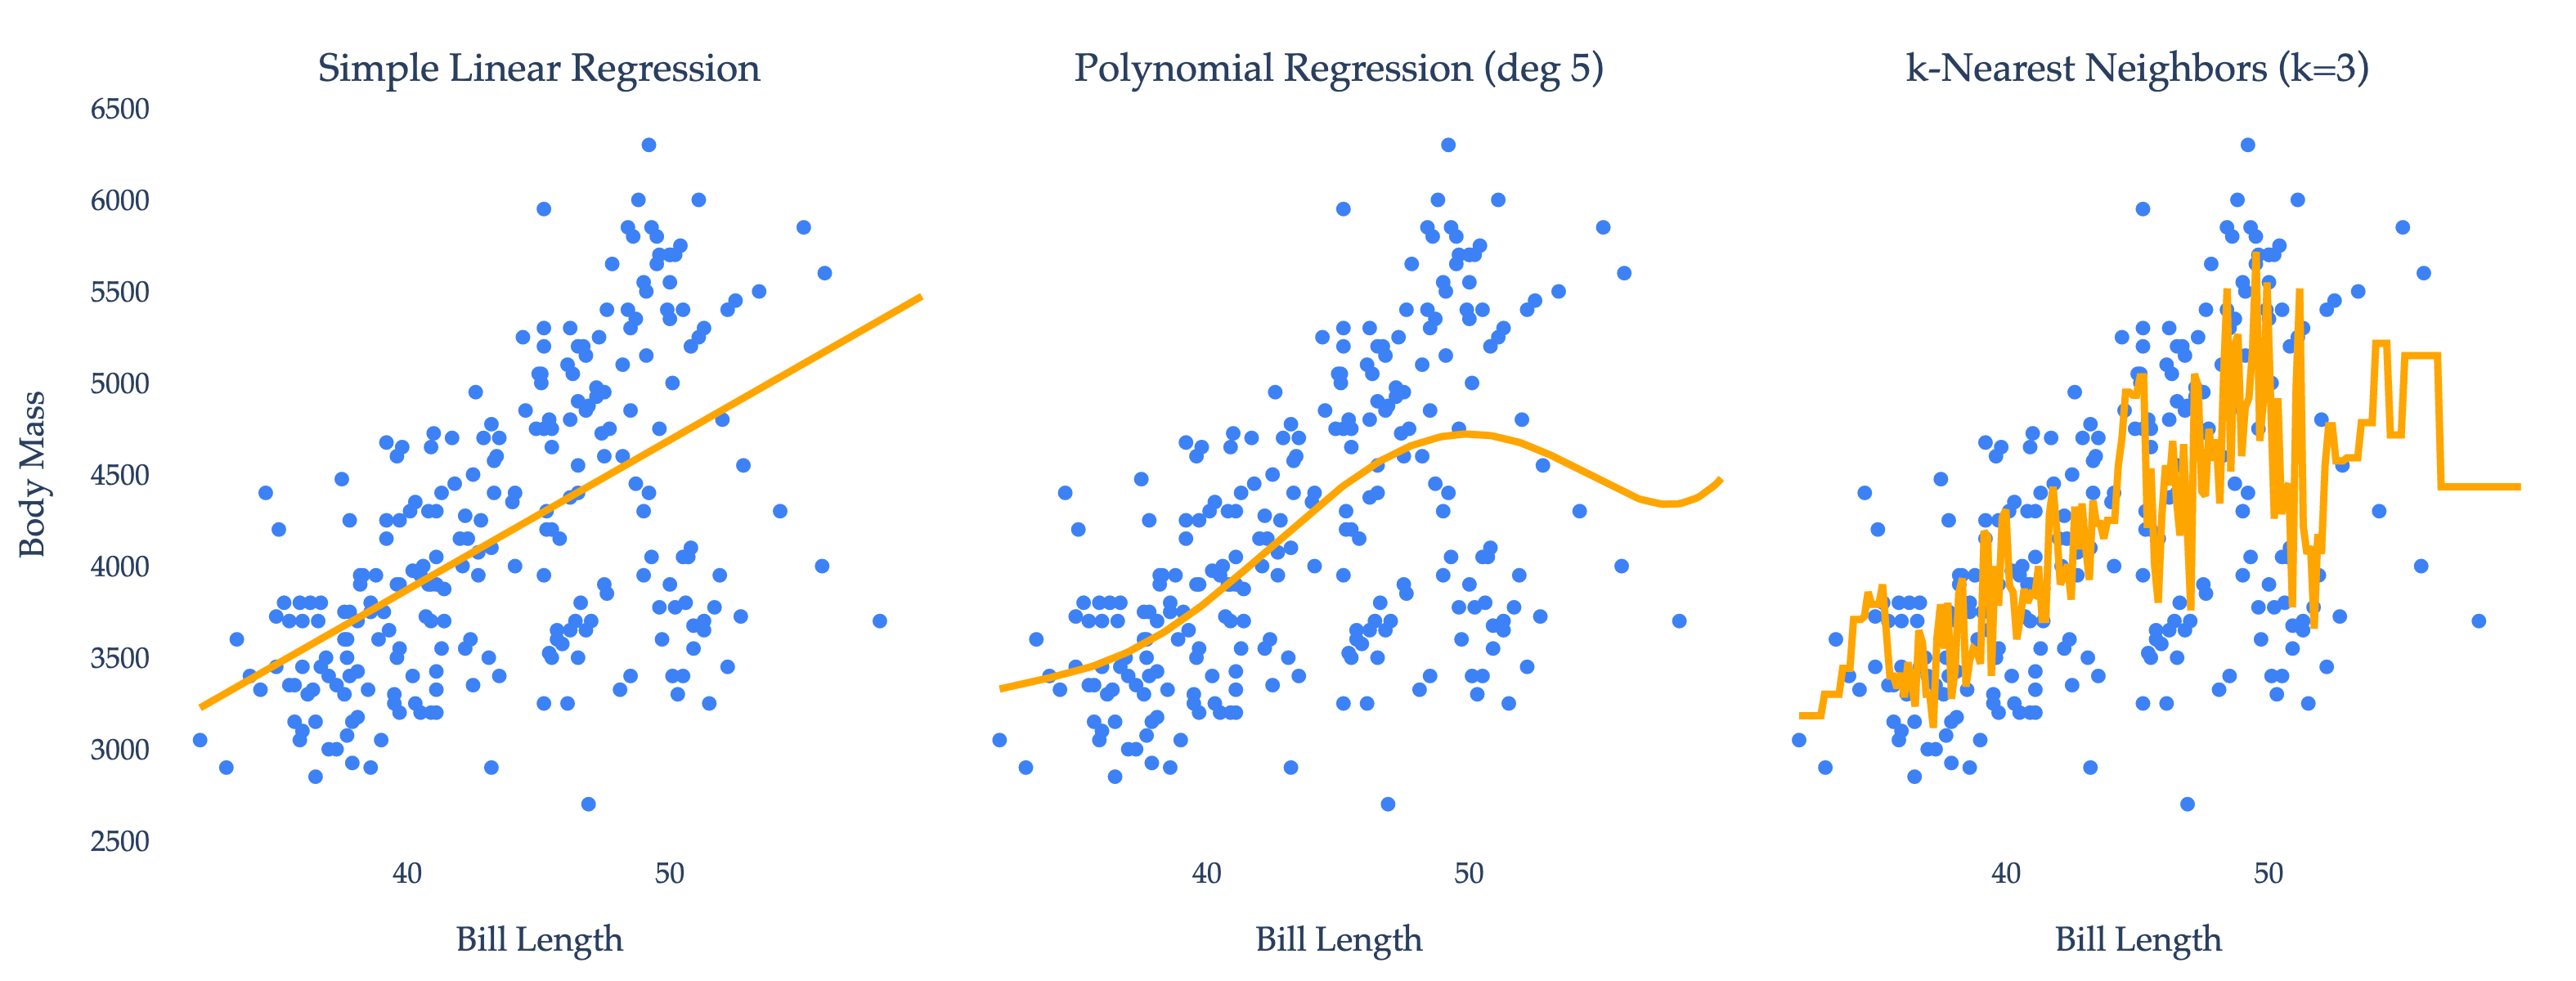

In [4]:
import warnings
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Suppress sklearn "was fitted with feature names" warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")

# Load and prepare data
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)
X = penguins[['bill_length_mm']]
y = penguins['body_mass_g']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=26)

# Prepare grid for predictions
bill_length_grid = np.linspace(X['bill_length_mm'].min(), X['bill_length_mm'].max(), 200).reshape(-1, 1)

# 1. OLS
ols = LinearRegression().fit(X_train, y_train)
ols_pred = ols.predict(bill_length_grid)

# 2. PolynomialFeatures (deg 3)
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
poly_reg = LinearRegression().fit(X_train_poly, y_train)
bill_length_grid_poly = poly.transform(bill_length_grid)
poly_pred = poly_reg.predict(bill_length_grid_poly)

# 3. kNN (k=3)
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(bill_length_grid)

# Plotting
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Simple Linear Regression", "Polynomial Regression (deg 5)", "k-Nearest Neighbors (k=3)"],
    shared_yaxes=True,
    horizontal_spacing=0.01  # Decreased from default (0.2) to reduce horizontal spacing
)

# OLS plot
fig.add_trace(
    go.Scatter(x=X_train['bill_length_mm'], y=y_train, mode='markers', marker=dict(color='#3d81f6'), name='Train', showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=bill_length_grid.flatten(), y=ols_pred, mode='lines', line=dict(color='orange', width=3), name='OLS', showlegend=False),
    row=1, col=1
)

# Polynomial plot
fig.add_trace(
    go.Scatter(x=X_train['bill_length_mm'], y=y_train, mode='markers', marker=dict(color='#3d81f6'), name='Train', showlegend=False),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=bill_length_grid.flatten(), y=poly_pred, mode='lines', line=dict(color='orange', width=3), name='Poly', showlegend=False),
    row=1, col=2
)

# kNN plot
fig.add_trace(
    go.Scatter(x=X_train['bill_length_mm'], y=y_train, mode='markers', marker=dict(color='#3d81f6'), name='Train', showlegend=False),
    row=1, col=3
)
fig.add_trace(
    go.Scatter(x=bill_length_grid.flatten(), y=knn_pred, mode='lines', line=dict(color='orange', width=3), name='kNN', showlegend=False),
    row=1, col=3
)

fig.update_xaxes(title_text="Bill Length", row=1, col=1)
fig.update_xaxes(title_text="Bill Length", row=1, col=2)
fig.update_xaxes(title_text="Bill Length", row=1, col=3)
fig.update_yaxes(title_text="Body Mass", row=1, col=1)

fig.update_layout(
    width=1050,
    height=400,
    margin=dict(l=40, r=20, t=40, b=40),
    font=dict(family="Palatino"),
    paper_bgcolor='white',
    plot_bgcolor='white',
    showlegend=False
)

fig.show(renderer='png', scale=3)

In [Chapter 1.2](02-squared-loss-constant-model.ipynb), we'll learn _how_ to find models that make good predictions, starting with (a simpler version of) the simple linear regression model from above. As we'll soon see, this linear regression model is called "simple" because it only takes in one input variable, or **feature** (bill length). "Multiple" linear regression models take in multiple features, e.g. if we used bill length and bill depth to predict body mass.

:::{tip} Activity 1
:class: dropdown

Identify whether each of the following problems is a classification or regression problem.

1. Given customer purchase history and demographics, predict whether they will buy a premium membership next month.
2. Using sensor data from manufacturing equipment, predict the remaining useful life of a machine component in hours.
3. Based on patient symptoms and vital signs, determine if treatment should be aggressive, moderate, or conservative.
4. Using weather data and soil conditions, predict crop yield per acre for the upcoming harvest season.
5. Given user behavior patterns on a website, predict which content category they will click on next.

:::

The distinction between classification and regression isn't always straightforward. For instance, predicting the exact number of times a customer will visit a website before making a purchase is considered a regression problem, even though the possible outcomes are limited to whole numbers like 0, 1, 2, 3, 4, 5, and so on, rather than any real value as in the other regression examples given above.

---

## Unsupervised Learning

In supervised learning, the computer is "supervised" by the correct answers in its goal to find a function that makes good predictions. But, what if we don't have any answers, and aren't trying to _predict_ anything?

:::{note} Definition: Unsupervised Learning

An unsupervised learning problem can be thought of as "given data, **find structure** in the data".

To train a model for an unsupervised learning problem, we do not need (and will not use) any labels.
:::

Our focus in this course will mostly be on supervised learning, but I'll briefly discuss two common forms of unsupervised learning: clustering and dimensionality reduction.

### Clustering

Imagine you work at Netflix, and keep track of the ratings each user gives to each TV show. You might want to find groups of users who have similar tastes, so that you can recommend shows to them that they're likely to enjoy.

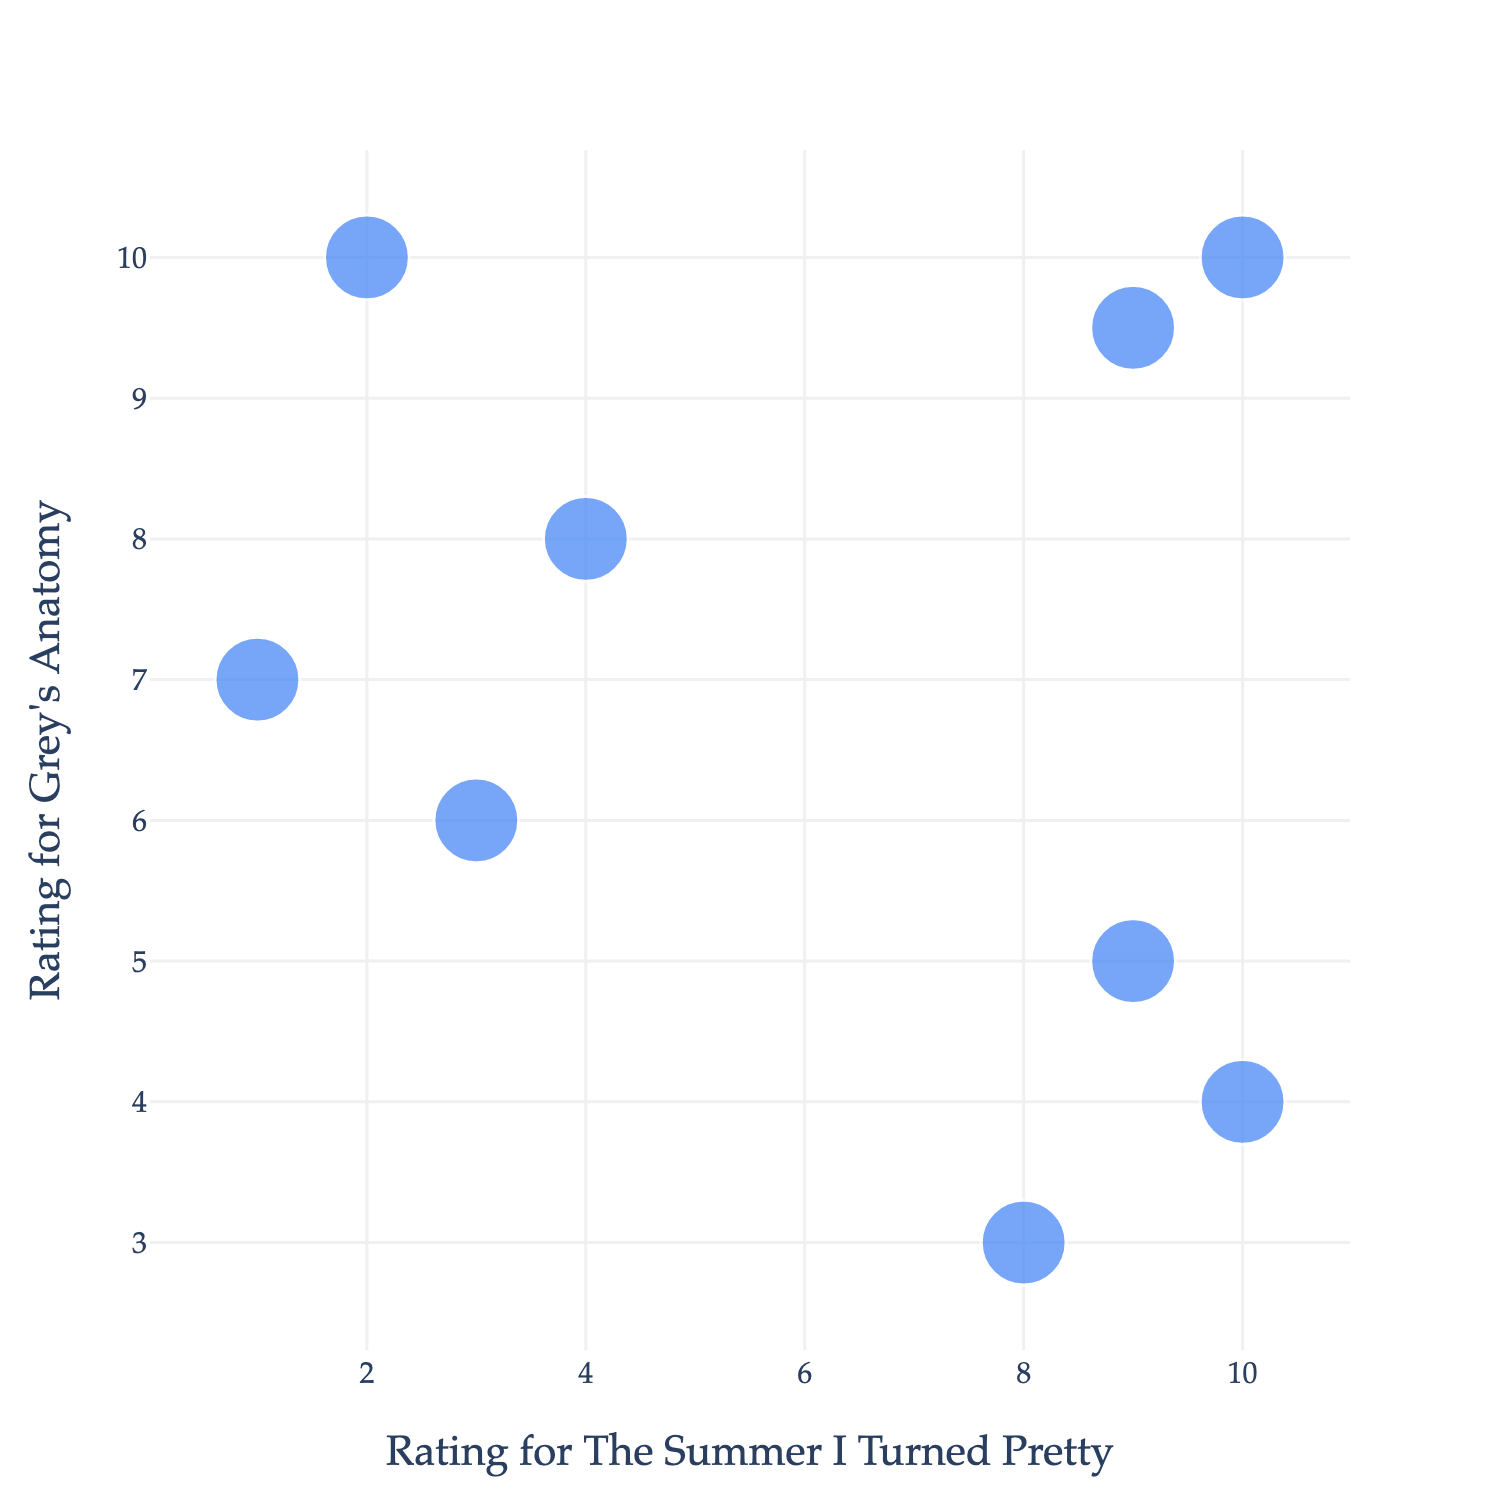

In [5]:
import plotly.express as px

x = np.array([1, 2, 3, 4, 8, 9, 10, 9, 10])
y = np.array([7, 10, 6, 8, 3, 5, 4, 9.5, 10])

fig = px.scatter(x=x, y=y, size_max=20, size=[10] * 9, color_discrete_sequence=['#3d81f6'])
fig.update_layout(
    width=500, 
    height=500,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family="Palatino"),
    margin=dict(l=50, r=50, t=50, b=50)
)
fig.update_xaxes(
    title='Rating for The Summer I Turned Pretty',
    gridcolor='#f0f0f0',
    zeroline=False,  # Remove the thick 0 line bar
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)
fig.update_yaxes(
    title='Rating for Grey\'s Anatomy',
    gridcolor='#f0f0f0',
    zeroline=False,  # Remove the thick 0 line bar
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)

fig.show(renderer='png', scale=3)

Neither of these shows are on Netflix, but they're what I spent the summer watching, so they'll have to work for now.

Each point in the plot above represents a single user. We _could_ try and predict a user's rating for Grey's Anatomy (GA) given their rating for The Summer I Turned Pretty (TSITP), which would be a supervised learning (regression) problem, but that's not what we're investigating now.

Instead, let's treat the data as unlabeled. You might notice that the data naturally falls into three groups, or **clusters**:
- The top-left group doesn't like TSITP (a romantic drama) but does like GA (a medical drama).
- The bottom-right group likes TSITP, but not GA.
- The top-right group likes both TSITP and GA.

If I could mathematically describe these clusters, I could use their boundaries to recommend shows to other users. For instance, if most users in the bottom-right cluster like, say, The Office, and some new user who hasn't watched The Office but likes TSITP and GA comes along, I could recommend The Office to them.

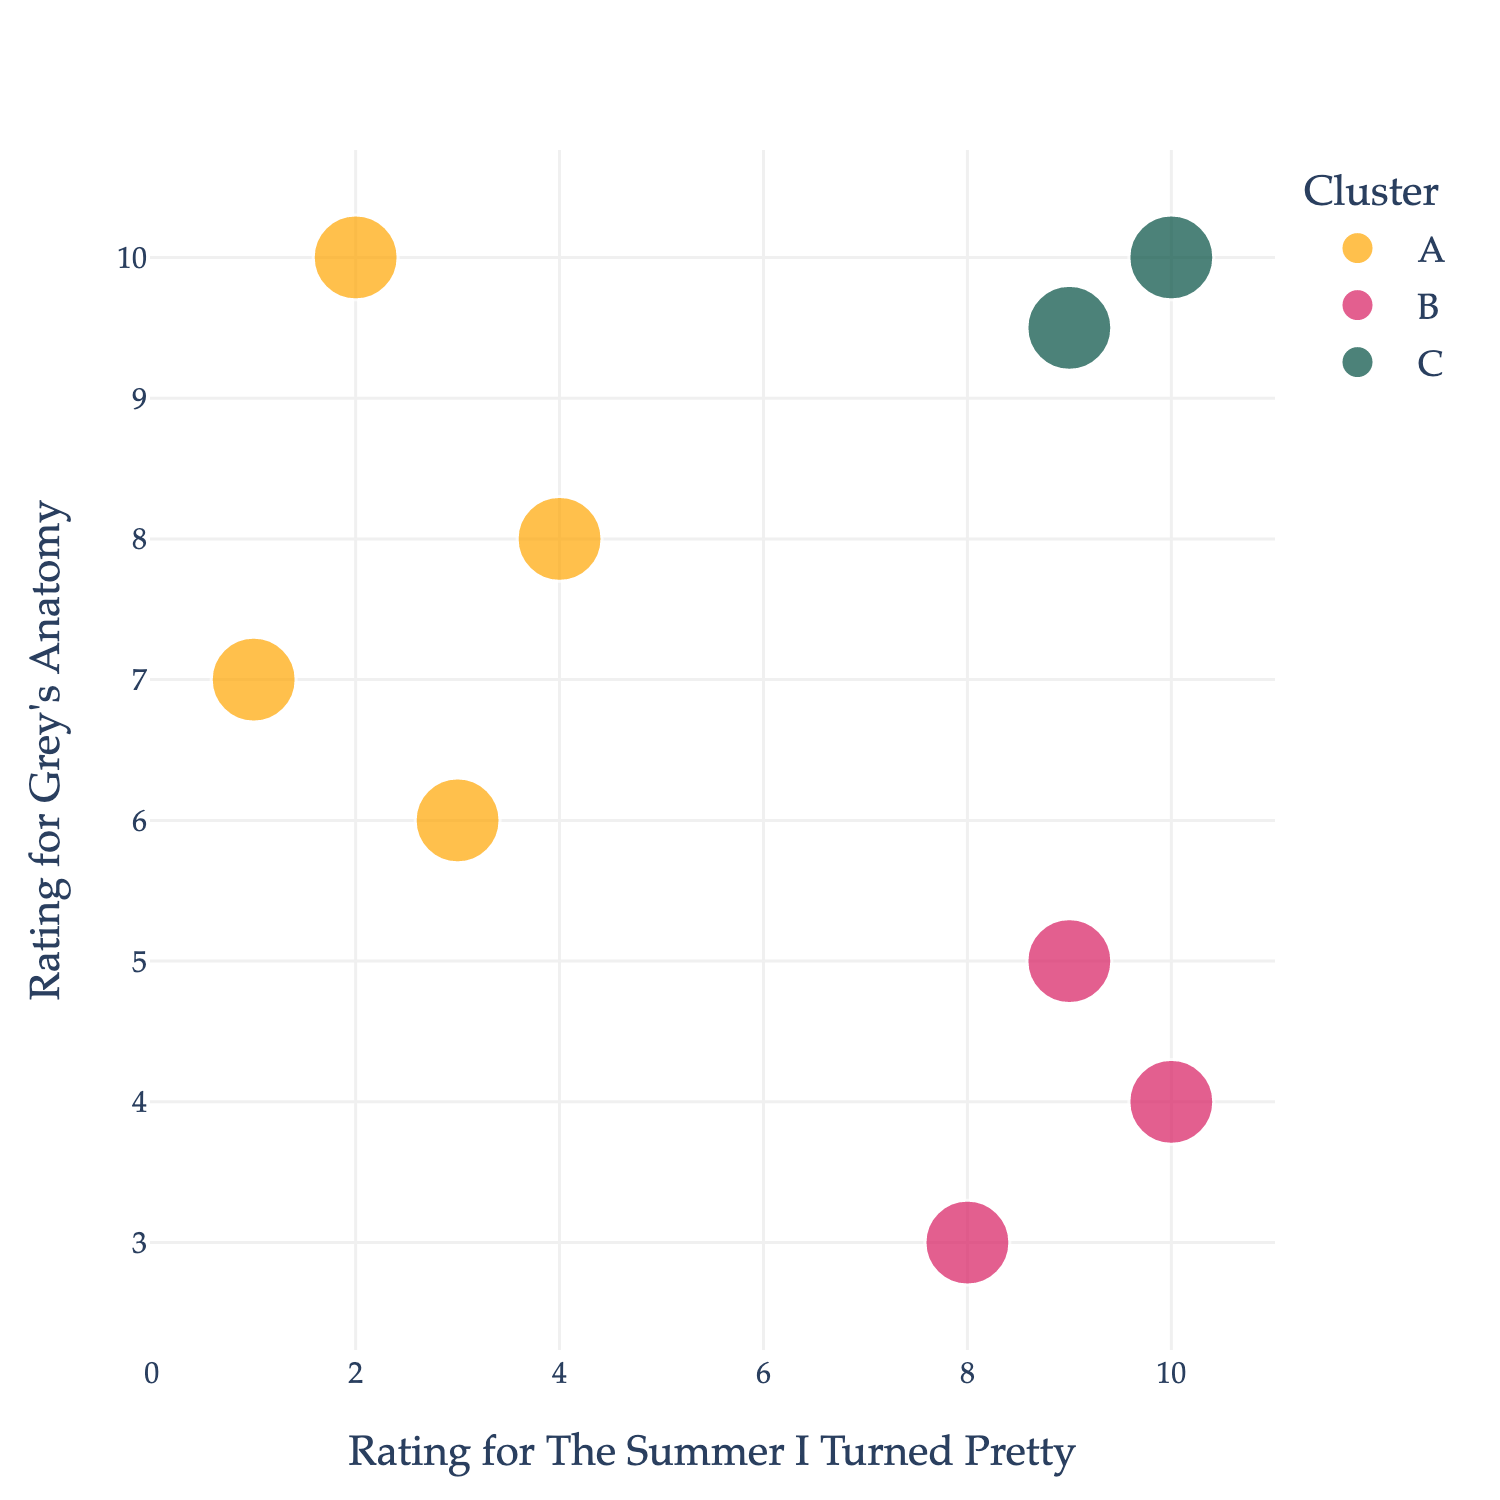

In [6]:
import plotly.express as px

# Assign cluster labels for the three groups
cluster_labels = ['A'] * 4 + ['B'] * 3 + ['C'] * 2  # 4, 3, 2 points per cluster

x = np.array([1, 2, 3, 4, 8, 9, 10, 9, 10])
y = np.array([7, 10, 6, 8, 3, 5, 4, 9.5, 10])

fig = px.scatter(
    x=x,
    y=y,
    color=cluster_labels,
    size_max=20,
    size=[10] * 9,
    color_discrete_map={
        'A': 'orange',
        'B': '#d81b60',
        'C': '#004d40'
    },
    labels={'color': 'Output of Clustering Algorithm'}
)
fig.update_layout(
    width=500, 
    height=500,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family="Palatino"),
    margin=dict(l=50, r=50, t=50, b=50),
    legend_title_text='Cluster'
)
fig.update_xaxes(
    title='Rating for The Summer I Turned Pretty',
    gridcolor='#f0f0f0',
    zeroline=False,
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)
fig.update_yaxes(
    title='Rating for Grey\'s Anatomy',
    gridcolor='#f0f0f0',
    zeroline=False,
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)

fig.show(renderer='png', scale=3)

:::{note} Definition: Clustering

The goal of clustering, an unsupervised learning problem, is to place data into groups of similar data points.
:::

Placing points into clusters seems easy in the example above, but in practice, Netflix has millions of users and thousands of shows, meaning that the data is too large to visualize, much less cluster by hand. There are a variety of clustering algorithms that exist, each with their own strengths and weaknesses. We will not discuss clustering in this course – you'll learn more in a future course dedicated to machine learning – but you can read more about how different clustering algorithms work [here](https://scikit-learn.org/stable/modules/clustering.html).

:::{tip} Activity 2
:class: dropdown

How would you explain the difference between clustering and classification to someone with no background in computer science or machine learning?
:::

### Dimensionality Reduction

As alluded to above, we'll soon work with datasets with features (pieces of information) for millions of individuals. We typically store this information in a table or matrix, where each row corresponds to an individual and each column corresponds to a feature.

To illustrate, let's return to the digit recognition example from the start of the section. I mentioned that each image in the dataset is a 28x28 pixel image, which means that to train the model, we're using $28 \cdot 28 = 784$ features per image. A table containing this information would have 70,000 rows (one per image) and 784 columns (one per pixel).

In [7]:
from sklearn.datasets import fetch_openml
import pandas as pd 

mnist = fetch_openml('mnist_784', version=1, as_frame=True)
mnist_df = mnist.frame
mnist_df.iloc[:, :-1]


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


:::{tip} Activity 3
:class: dropdown

Why do you think most of the values above are 0?
:::

This dataset is far too high-dimensional to visualize all at once – to draw a scatter plot as we did in earlier examples above, we'd need to be able to see 784 dimensions at once, while we can only see 3. We can look at a few images at a time, but we have no tool for visualizing the entire dataset.

That's where dimensionality reduction comes in.

:::{note} Definition: Dimensionality Reduction

Dimensionality reduction is an unsupervised learning technique for reducing the number of features in a dataset while preserving the information in the dataset.
:::

A naïve approach to dimensionality reduction would be to simply drop some of the features. For instance, if we wanted to draw a scatter plot containing all 70,000 images, we could pick just 2 of the 784 features (pixels) to plot against each other. But, this would lose a lot of information, as just two pixels don't tell us much about an image.

More sophisticated approaches, like principal component analysis (PCA), can "invent" new features that capture the most important information in the dataset.

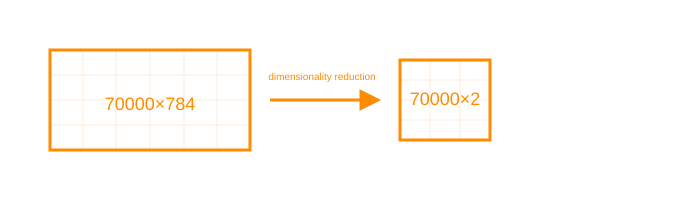

In [22]:
from IPython.display import SVG

s = '''<svg viewBox="0 0 700 200" xmlns="http://www.w3.org/2000/svg">
  <!-- Original 70000x784 matrix (wide rectangle) -->
  <rect x="50" y="50" 
        width="200" height="100" 
        fill="none" 
        stroke="#FF8C00" 
        stroke-width="3"/>
  
  <!-- Matrix dimensions label for 70000x784 -->
  <text x="150" y="110" 
        font-family="Avenir, Arial, sans-serif" 
        font-size="18" 
        font-weight="500"
        text-anchor="middle" 
        fill="#FF8C00">70000×784</text>
  
  <!-- Arrow showing dimensionality reduction -->
  <line x1="270" y1="100" x2="360" y2="100" 
        stroke="#FF8C00" 
        stroke-width="3"/>
  <polygon points="360,90 380,100 360,110" 
           fill="#FF8C00" 
           stroke="#FF8C00" 
           stroke-width="1"/>
  
  <!-- "PCA" label above arrow -->
  <text x="322" y="80" 
        font-family="Avenir, Arial, sans-serif" 
        font-size="10" 
        font-weight="400"
        text-anchor="middle" 
        fill="#FF8C00">dimensionality reduction</text>
  
  <!-- Reduced 70000x2 matrix (wider rectangle) -->
  <rect x="400" y="60" 
        width="90" height="80" 
        fill="none" 
        stroke="#FF8C00" 
        stroke-width="3"/>
  
  <!-- Matrix dimensions label for 70000x2 -->
  <text x="445" y="105" 
        font-family="Avenir, Arial, sans-serif" 
        font-size="18" 
        font-weight="500"
        text-anchor="middle" 
        fill="#FF8C00">70000×2</text>
  
  <!-- Subtle grid lines to suggest matrix structure -->
  <!-- Original matrix grid -->
  <g stroke="#FF8C00" stroke-width="0.5" opacity="0.3">
    <!-- Vertical lines for original matrix (evenly spaced within bounds) -->
    <line x1="83" y1="50" x2="83" y2="150"/>
    <line x1="116" y1="50" x2="116" y2="150"/>
    <line x1="150" y1="50" x2="150" y2="150"/>
    <line x1="184" y1="50" x2="184" y2="150"/>
    <line x1="217" y1="50" x2="217" y2="150"/>
    
    <!-- Horizontal lines for original matrix -->
    <line x1="50" y1="75" x2="250" y2="75"/>
    <line x1="50" y1="100" x2="250" y2="100"/>
    <line x1="50" y1="125" x2="250" y2="125"/>
  </g>
  
  <!-- Reduced matrix grid -->
  <g stroke="#FF8C00" stroke-width="0.5" opacity="0.3">
    <!-- Vertical lines for reduced matrix -->
    <line x1="430" y1="60" x2="430" y2="140"/>
    <line x1="460" y1="60" x2="460" y2="140"/>
    <line x1="490" y1="60" x2="490" y2="140"/>
    
    <!-- Horizontal lines for reduced matrix -->
    <line x1="400" y1="80" x2="490" y2="80"/>
    <line x1="400" y1="100" x2="490" y2="100"/>
    <line x1="400" y1="120" x2="490" y2="120"/>
  </g>
</svg>'''

SVG(s)

Below, you'll find the result of applying PCA to the MNIST dataset. **Each point corresponds to an image.** We've actually only included a random sample of 10,000 of the 70,000 images, as the full dataset would crowd the plot too much.

In [33]:
from sklearn.decomposition import PCA
import plotly.express as px

np.random.seed(26)
mnist_df_sample = mnist_df.sample(10000, random_state=26).reset_index(drop=True)

# Ensure the color column is string, but sorted by digit order
digit_labels = mnist_df_sample.iloc[:, -1].astype(int)
sorted_labels = [str(d) for d in sorted(digit_labels.unique())]

pca = PCA(n_components=2)
mnist_pca = pca.fit_transform(mnist_df_sample.iloc[:, :-1])

fig = px.scatter(
    x=mnist_pca[:, 0],
    y=mnist_pca[:, 1],
    color=digit_labels.astype(str),
    category_orders={'color': sorted_labels},
    labels={'x': 'PCA Invented Feature 1', 'y': 'PCA Invented Feature 2', 'color': 'Digit'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_traces(marker=dict(size=8, opacity=0.8), selector=dict(mode='markers'))
fig.update_layout(
    legend_title_text='Digit',
    width=650,
    height=500,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family="Palatino"),
    margin=dict(l=40, r=40, t=60, b=40)
)
fig.update_xaxes(
    gridcolor='#f0f0f0',
    zeroline=False,
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)
fig.update_yaxes(
    gridcolor='#f0f0f0',
    zeroline=False,
    tickfont=dict(size=10, family="Palatino"),
    title_font=dict(family="Palatino")
)

fig.show(renderer='notebook')

The PCA process **did not** use the labels in the dataset, i.e. it did not factor in whether the image was actually of a 0, 1, 2, 3, etc. when inventing these two new features. But, you'll notice that in the plot of new feature 2 vs. new feature 1, the images are roughly clustered by true digit! For example, the <span style="color: #854491; font-weight: bold;">0s (middle right)</span> all look similar to one another in 2D space. The plot above is interactive, so you can hover over a point to see its true digit.

We will cover PCA in depth in [Chapter 10](../10_singular_value_decomposition/00-index.ipynb) of these notes – it is surprisingly involved, and requires a deep understanding of linear algebra to fully grasp. All in due time!

---

## Reinforcement Learning

Reinforcement learning is less about finding a function that makes good predictions or finding structure in data, and more about finding a function (formally called a **policy**) that **makes good decisions**. Reinforcement learning is likened to the way humans pick up new skills, like cooking or riding a bike – by trying something, failing, and trying again, now equipped with the knowledge of what worked and what didn't.

Perhaps the most famous example of reinforcement learning is AlphaGo, a model trained by Google DeepMind to play the game [Go](https://en.wikipedia.org/wiki/Go_(game)). Go is a board game similar to chess or checkers, but with a 19x19 grid and more sophisticated rules. To train AlphaGo, first, researchers showed the model 30 million games of Go played by human players. Then, they had the model play many games of Go **against itself**, giving it a **reward** for winning and a **penalty** for losing. Eventually, through trial-and-error, the model learned to play Go at a higher level than the human players. In 2016, AlphaGo defeated the reigning world champion at the time.


:::{figure} 01-intro-imgs/alphago.jpg
:figclass: with-caption center
:width: 600

Watch the AlphaGo [documentary](https://www.youtube.com/watch?v=WXuK6gekU1Y) for free on YouTube.
:::

We won't discuss reinforcement learning any further in this course. If you'd like to learn more, start by reading [this blog post](https://blog.google/technology/ai/alphago-machine-learning-game-go/). It was written by Demis Hassabis, the CEO of Google DeepMind – who also recently won the Nobel Prize in Chemistry – and explains the inner workings of AlphaGo in 2016 _before_ it beat the world champion. I like this post not only because it's written in a way that's accessible to non-technical readers, but also because it shows you a snapshot of the growing excitement surrounding machine learning a decade ago.

---

## Deep Learning

"Deep learning" is a popular term that doesn't appear in the [taxonomy](#supervised-learning) I presented earlier, but it's a term you've probably heard of.

All three types of machine learning – supervised learning, unsupervised learning, and reinforcement learning – could involve "deep learning", which really just means machine learning using neural networks. Neural networks are called "deep" because they can have many "layers" of computation, i.e. many functions that are applied to the input data before returning a prediction, representation, or action.

For example, here's a neural network with several layers, that could be used to predict the species of a penguin given its bill length and body mass, by first predicting the probability of each species.

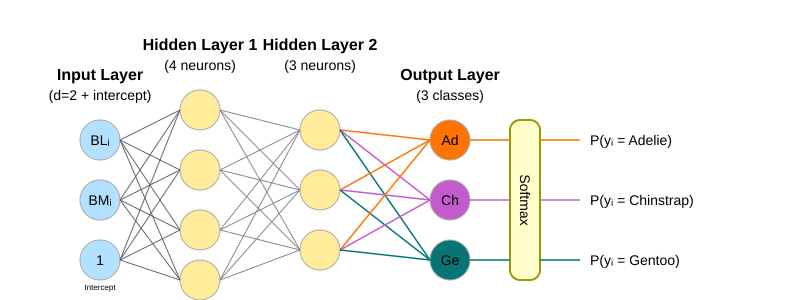

In [29]:
from IPython.display import SVG

SVG('''
<svg viewBox="0 0 800 300" xmlns="http://www.w3.org/2000/svg">
  <!-- Background styling -->
  <rect width="800" height="300" fill="white"/>
  
  <!-- Input Layer Nodes -->
  <circle cx="100" cy="140" r="20" fill="#b3e0ff" stroke="#aaa" stroke-width="1"/>
  <circle cx="100" cy="200" r="20" fill="#b3e0ff" stroke="#aaa" stroke-width="1"/>
  <circle cx="100" cy="260" r="20" fill="#b3e0ff" stroke="#aaa" stroke-width="1"/>
  
  <!-- Input Layer Labels -->
  <text x="100" y="145" text-anchor="middle" font-family="Arial" font-size="14">BLᵢ</text>
  <text x="100" y="205" text-anchor="middle" font-family="Arial" font-size="14">BMᵢ</text>
  <text x="100" y="265" text-anchor="middle" font-family="Arial" font-size="14">1</text>
  <text x="100" y="290" text-anchor="middle" font-family="Arial" font-size="8">Intercept</text>
  
  <!-- First Hidden Layer Nodes -->
  <circle cx="200" cy="110" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  <circle cx="200" cy="170" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  <circle cx="200" cy="230" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  <circle cx="200" cy="280" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  
  <!-- Second Hidden Layer Nodes -->
  <circle cx="320" cy="130" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  <circle cx="320" cy="190" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  <circle cx="320" cy="250" r="20" fill="#ffeb99" stroke="#aaa" stroke-width="1"/>
  
  <!-- Output Layer Nodes -->
  <circle cx="450" cy="140" r="20" fill="#ff7400" stroke="#aaa" stroke-width="1"/>
  <circle cx="450" cy="200" r="20" fill="#c45bcc" stroke="#aaa" stroke-width="1"/>
  <circle cx="450" cy="260" r="20" fill="#077575" stroke="#aaa" stroke-width="1"/>
  
  <!-- Output Layer Labels -->
  <text x="450" y="145" text-anchor="middle" font-family="Arial" font-size="14">Ad</text>
  <text x="450" y="205" text-anchor="middle" font-family="Arial" font-size="14">Ch</text>
  <text x="450" y="265" text-anchor="middle" font-family="Arial" font-size="14">Ge</text>
  
  <!-- Connections from Input to First Hidden -->
  <!-- BL to all first hidden nodes -->
  <line x1="120" y1="140" x2="180" y2="110" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="140" x2="180" y2="170" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="140" x2="180" y2="230" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="140" x2="180" y2="280" stroke="#666" stroke-width="1"/>
  
  <!-- BM to all first hidden nodes -->
  <line x1="120" y1="200" x2="180" y2="110" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="200" x2="180" y2="170" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="200" x2="180" y2="230" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="200" x2="180" y2="280" stroke="#666" stroke-width="1"/>
  
  <!-- Bias to all first hidden nodes -->
  <line x1="120" y1="260" x2="180" y2="110" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="260" x2="180" y2="170" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="260" x2="180" y2="230" stroke="#666" stroke-width="1"/>
  <line x1="120" y1="260" x2="180" y2="280" stroke="#666" stroke-width="1"/>
  
  <!-- Connections from First Hidden to Second Hidden -->
  <!-- First hidden layer to second hidden layer -->
  <line x1="220" y1="110" x2="300" y2="130" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="110" x2="300" y2="190" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="110" x2="300" y2="250" stroke="#888" stroke-width="1"/>
  
  <line x1="220" y1="170" x2="300" y2="130" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="170" x2="300" y2="190" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="170" x2="300" y2="250" stroke="#888" stroke-width="1"/>
  
  <line x1="220" y1="230" x2="300" y2="130" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="230" x2="300" y2="190" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="230" x2="300" y2="250" stroke="#888" stroke-width="1"/>
  
  <line x1="220" y1="280" x2="300" y2="130" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="280" x2="300" y2="190" stroke="#888" stroke-width="1"/>
  <line x1="220" y1="280" x2="300" y2="250" stroke="#888" stroke-width="1"/>
  
  <!-- Connections from Second Hidden to Output -->
  <!-- Second hidden to all outputs -->
  <line x1="340" y1="130" x2="430" y2="140" stroke="#ff7400" stroke-width="1.5"/>
  <line x1="340" y1="130" x2="430" y2="200" stroke="#c45bcc" stroke-width="1.5"/>
  <line x1="340" y1="130" x2="430" y2="260" stroke="#077575" stroke-width="1.5"/>
  
  <line x1="340" y1="190" x2="430" y2="140" stroke="#ff7400" stroke-width="1.5"/>
  <line x1="340" y1="190" x2="430" y2="200" stroke="#c45bcc" stroke-width="1.5"/>
  <line x1="340" y1="190" x2="430" y2="260" stroke="#077575" stroke-width="1.5"/>
  
  <line x1="340" y1="250" x2="430" y2="140" stroke="#ff7400" stroke-width="1.5"/>
  <line x1="340" y1="250" x2="430" y2="200" stroke="#c45bcc" stroke-width="1.5"/>
  <line x1="340" y1="250" x2="430" y2="260" stroke="#077575" stroke-width="1.5"/>
  
  <!-- Layer Labels -->
  <text x="100" y="80" text-anchor="middle" font-family="Arial" font-size="16" font-weight="bold">Input Layer</text>
  <text x="100" y="100" text-anchor="middle" font-family="Arial" font-size="14">(d=2 + intercept)</text>
  
  <text x="200" y="50" text-anchor="middle" font-family="Arial" font-size="16" font-weight="bold">Hidden Layer 1</text>
  <text x="200" y="70" text-anchor="middle" font-family="Arial" font-size="14">(4 neurons)</text>
  
  <text x="320" y="50" text-anchor="middle" font-family="Arial" font-size="16" font-weight="bold">Hidden Layer 2</text>
  <text x="320" y="70" text-anchor="middle" font-family="Arial" font-size="14">(3 neurons)</text>
  
  <text x="450" y="80" text-anchor="middle" font-family="Arial" font-size="16" font-weight="bold">Output Layer</text>
  <text x="450" y="100" text-anchor="middle" font-family="Arial" font-size="14">(3 classes)</text>
  
  <!-- Softmax Function -->
  <rect x="510" y="120" width="30" height="160" rx="10" ry="10" fill="#ffffcc" stroke="#999900" stroke-width="2"/>
  <text x="550" y="230" text-anchor="middle" font-family="Arial" font-size="14" transform="rotate(90,550,200)">Softmax</text>
  
  <!-- Arrows from output to softmax -->
  <line x1="470" y1="140" x2="510" y2="140" stroke="#ff7400" stroke-width="1.5"/>
  <line x1="470" y1="200" x2="510" y2="200" stroke="#c45bcc" stroke-width="1.5"/>
  <line x1="470" y1="260" x2="510" y2="260" stroke="#077575" stroke-width="1.5"/>
  
  <!-- Probability outputs -->
  <line x1="540" y1="140" x2="580" y2="140" stroke="#ff7400" stroke-width="1.5"/>
  <line x1="540" y1="200" x2="580" y2="200" stroke="#c45bcc" stroke-width="1.5"/>
  <line x1="540" y1="260" x2="580" y2="260" stroke="#077575" stroke-width="1.5"/>
  
  <!-- Probability labels -->
  <text x="590" y="145" text-anchor="start" font-family="Arial" font-size="14">P(yᵢ = Adelie)</text>
  <text x="590" y="205" text-anchor="start" font-family="Arial" font-size="14">P(yᵢ = Chinstrap)</text>
  <text x="590" y="265" text-anchor="start" font-family="Arial" font-size="14">P(yᵢ = Gentoo)</text>
</svg>''')

While we won't spend much time on neural networks in this course – you'll need to wait for your next machine learning course to see them in depth – we **will** spend the entire semester understanding all of the operations they use and how they work together. Every line, circle, and box you see in the diagram above represents some sort of operation in linear algebra.

---

## Large Language Models

I've given you an overview of three big branches of machine learning: supervised learning, unsupervised learning, and reinforcement learning. What's not clear is how large language models, like ChatGPT, fit into this taxonomy. It turns out that large language models are created using **all three of these types of machine learning** (and also deep learning).

:::{note} Definition: Language Model

A language model is a model that predicts the next word in a sequence of words.
:::

A language model is trained on a collection of text documents, called a **corpus**. To illustrate how they work, let's look at a small example corpus.

<center><b>is the <span style="color: #3d81f6;">umich</span></b> the best? my friend said ucsd <b>is the <span style="color: orange;">best</span></b>, <b>is the <span style="color: #3d81f6;">umich</span></b> better?</center>

Think of predicting the next word in a sequence of words as implementing randomized, intelligent autocomplete, using patterns from data. For instance, if we start with the phrase "**is the**", a language model trained on this corpus might predict "<b><span style="color: #3d81f6;">umich</span></b>" or "<b><span style="color: orange;">best</span></b>" as the next word, since both "<b>is the <span style="color: #3d81f6;">umich</span></b>" and "<b>is the <span style="color: orange;">best</span></b>" appear in the corpus. It probably wouldn't predict "friend" as the next word, as "is the friend" doesn't appear in the corpus.

"<b>is the <span style="color: #3d81f6;">umich</span></b>" appears twice as often as "<b>is the <span style="color: orange;">best</span></b>". Language models estimate **probabilities**, so a language model trained on this specific corpus would learn:

$$\mathbb{P}({\color{#3d81f6} \text{``umich"}} \mid \text{``is the"}) = \frac{2}{3} \\ \mathbb{P}({\color{orange} \text{``best"}} \mid \text{``is the"}) = \frac{1}{3}$$

In order for language models to produce natural-sounding text, researchers have found that they need to use some randomness in how they generate outputs. So, instead of always autocompleting "**is the**" with the most likely word (i.e., "<b><span style="color: #3d81f6;">umich</span></b>"), they sample from a distribution of words, weighted by the probabilities learned above. So, $\frac{2}{3}$ of the time, the model will autocomplete "**is the**" with "<b><span style="color: #3d81f6;">umich</span></b>", and $\frac{1}{3}$ of the time, it will autocomplete "**is the**" with "<b><span style="color: orange;">best</span></b>". Then, it'll continue to predict the next word in the sequence, using the last few words as context. This explanation is a bit simplistic, but captures the gist of how language models work at a high level.

A **large** language model (LLM) is a language model that is trained on a **large** (massive!) dataset of text. The recently released GPT-5, and its predecessors, GPT-4 and GPT-3.5, are all LLMs created by OpenAI; ChatGPT is a chatbot that uses GPT for autocompletion, with some additional logic to make the interactions seem more natural. Claude, Gemini, and Grok are also LLMs, created by Anthropic, Google, and X (formerly Twitter), respectively. 

The corpuses for these LLMs are **trillions** of words long, containing books, most publicly available websites, and more; since they were trained on such massive datasets, they are able to answer questions about a broad range of topics. With the above explanation in mind, it's not hard to see why LLMs sometimes output realistic-sounding text that is not actually true – they randomly generate sequences of words that are statistically likely to appear in their corpuses, but not necessarily true.

All three of the branches of machine learning – supervised learning, unsupervised learning, and reinforcement learning – play a role in training LLMs.

:::{figure} 01-intro-imgs/sft.jpg
:figclass: with-caption center
:width: 600

The three stages of LLM training ([image source](https://cameronrwolfe.substack.com/p/specialized-llms-chatgpt-lamda-galactica?open=false#%C2%A7training-language-models-to-follow-instructions-with-human-feedback); [more reading from OpenAI](https://openai.com/index/instruction-following/)).
:::

1. First, an LLM is taught how to predict the next word in a sequence of words, by estimating probabilities like $\mathbb{P}(\text{``umich"} \mid \text{``is the"})$. In this task, there are no labels – the "labels" come from the corpus of text itself. So, this first stage – called **pre-training** – is somewhere in between supervised learning (because it's predicting) and unsupervised learning (because there are no labels), and is often thought of as **self-supervised learning**.
1. Then, more supervised learning – specifically, **supervised fine-tuning (SFT)** – is used to train the LLM to get better at answering questions for any one particular task, using a dataset of questions $x$ and ideal answers $y$ created by humans.
1. Finally, to ensure the LLM gives answers that humans find useful, it is repeatedly asked a question, and humans vote on their favorite answers. These human preferences are used to create a **reward function** that the LLM can use to improve its answers using reinforcement learning (sometimes called **reinforcement learning with human feedback (RLHF)**).

Neural networks – and more specifically, the transformer architecture – are the computational backbone that makes all these steps possible. Transformers, first introduced in 2017 by researchers at Google in a [now-famous paper](https://arxiv.org/abs/1706.03762), are excellent at extracting meaning from text data out-of-order. For instance, in the sentence "The bank was steep," a transformer can distinguish that "bank" refers to a riverbank rather than a financial institution by considering the context provided by "steep", even though the word "bank" appears before "steep" in the sentence. For a detailed technical introduction to how transformers work, see the [transformers course by Hugging Face](https://huggingface.co/learn/llm-course/en/chapter1/4).

Training state-of-the-art LLMs is a resource-intensive process – some insiders estimate that training OpenAI's new GPT-5 cost a few **billion** dollars and several months. You and I (probably) don't have billions of dollars, but we do have a few months together, and in that time, we will learn about the mathematical underpinnings that make this all possible.